In [17]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()
llm = ChatGroq(
    model='openai/gpt-oss-20b',
    temperature=0.1
)



In [18]:
from pydantic import BaseModel,Field

class State(BaseModel):
    topic:str = Field(description="This is topic on which user have to made post")
    post:str=Field(description="This is post on given topic")
    curated_post:str=Field(description="curated post of real post")



In [21]:
def create_post(state:State) -> State:
    topic = state.topic
    res = llm.invoke(f"Made post on this topic: {topic}").content
    state.post = res
    return state

def curated_post(state:State) -> State:
    post = state.post
    res = llm.invoke(f"change content of given post to gujrati funny version post-content : {post}").content
    state.curated_post = res
    return state


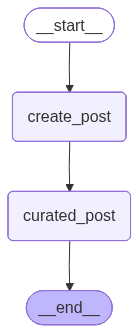

In [22]:
from langgraph.graph import StateGraph,START,END
from IPython.display import Image

graph = StateGraph(State)

graph.add_node('create_post',create_post)
graph.add_node('curated_post',curated_post)

graph.add_edge(START,'create_post')
graph.add_edge('create_post','curated_post')
graph.add_edge('curated_post',END)

pydantic_graph = graph.compile()

Image(pydantic_graph.get_graph().draw_mermaid_png())

In [ ]:
output = pydantic_graph.invoke({'topic':'moonsoon in world','post':'','curated_post':''})
output


{'topic': 'moonsoon in world',
 'post': 'Sure! Below is a quick‑start guide you can use to shape a compelling post about monsoons around the world.  \nFeel free to tweak the structure, add your own voice, or let me know if you’d like deeper dives into any section.\n\n---\n\n## 🌍 “Monsoon in the World” – Post Outline & Key Points\n\n| Section | What to Cover | Why It Matters | Quick Tips |\n|---------|---------------|----------------|------------|\n| **1. Hook / Opening** | Start with a striking fact or anecdote (e.g., “Every year, the Indian monsoon brings 1.5\u202f×\u202f10¹⁰\u202fkg of rain to a single city”). | Grabs attention and sets the stakes. | Use a vivid image or a surprising statistic. |\n| **2. What Is a Monsoon?** | • Definition: seasonal reversal of wind patterns that brings heavy rainfall.<br>• Key drivers: land‑sea temperature contrast, Coriolis effect, and atmospheric pressure systems. | Gives readers a clear, concise foundation. | Keep it short—think “monsoon = season